In [1]:
import kairo
import pandas as pd

import warnings
warnings.filterwarnings("ignore")

from dotenv import load_dotenv
from pathlib import Path
import os

load_dotenv(Path("..") / ".env")

True

In [2]:
log = kairo.read_log("../data/drifted_logs/time_fast/sudden/bank_account_closure/bank_account_closure_time_fast_x05_sudden.xes",
    case_id = "case:concept:name",
    activity = "concept:name",
    timestamp = "time:timestamp",
    #event_id = "event:uidd",
    start_timestamp = "start:timestamp",
    resource = "org:resource",
    #event_duration = "event:runtime_min")
    )
log.head()

parsing log, completed traces :: 100%|██████████████████████████████████████████████████████████████████████████████████████████| 32429/32429 [00:02<00:00, 11119.80it/s]


,concept:name,start_timestamp,time:timestamp,org:resource,org:role,lifecycle:transition,CLOSURE_TYPE,CLOSURE_REASON,case:concept:name
0,Request created,2017-05-29 08:47:46+00:00,2017-05-29 08:49:25+00:00,6,APPLICANT,complete,Client Recess,1 - Client lost,case_000000
1,Evaluating Request (NO registered letter),2017-05-29 08:49:25+00:00,2017-05-29 08:52:49+00:00,7,DIRECTOR,complete,Client Recess,1 - Client lost,case_000000
2,Service closure Request with network responsib...,2017-05-29 08:56:04+00:00,2017-05-29 09:02:39+00:00,7,APPLICANT,complete,Client Recess,1 - Client lost,case_000000
3,Service closure Request with BO responsibility,2017-05-29 09:02:39+00:00,2017-05-29 11:23:33+00:00,BOF,BACK-OFFICE,complete,Client Recess,1 - Client lost,case_000000
4,Network Adjustment Requested,2017-05-29 11:23:33+00:00,2017-05-31 09:26:08+00:00,7,APPLICANT,complete,Client Recess,1 - Client lost,case_000000


In [3]:
stats = kairo.compute_log_stats(log)
stats

{'cases': 32429,
 'events': 212721,
 'activities': 15,
 'resources': 654,
 'start': Timestamp('2017-05-29 08:49:25+0000', tz='UTC'),
 'end': Timestamp('2019-03-06 16:38:59+0000', tz='UTC'),
 'span_minutes': 930709.5666666667,
 'tpt_days_min': 0.0,
 'tpt_days_mean': 13.45629664160194,
 'tpt_days_median': 6.074346064814815,
 'tpt_days_max': 503.5870949074074,
 'length_min': 2,
 'length_mean': 6.559591723457399,
 'length_median': 7.0,
 'length_max': 23,
 'activity_counts': concept:name
 Request created                                        32377
 Service closure Request with BO responsibility         30130
 Pending Request for Reservation Closure                29151
 Request completed with account closure                 29031
 Pending Liquidation Request                            29000
 Service closure Request with network responsibility    25009
 Authorization Requested                                12675
 Evaluating Request (NO registered letter)              11080
 Back-Office Adj

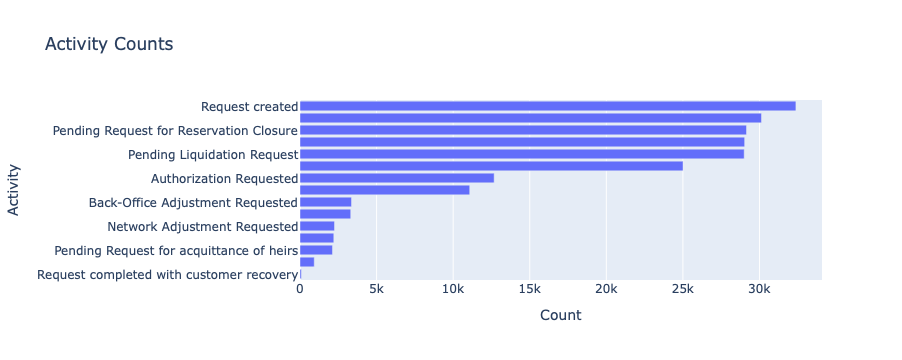

In [4]:
activity_plot = kairo.plot_activity_counts(stats)
activity_plot.show()

In [5]:
features = kairo.compute_features_intra(log, sliding_window_size=1)
features

,case:concept:name,time:timestamp,act_freqs:Authorization Requested,act_freqs:Back-Office Adjustment Requested,act_freqs:Evaluating Request (NO registered letter),act_freqs:Evaluating Request (WITH registered letter),act_freqs:Network Adjustment Requested,act_freqs:Pending Liquidation Request,act_freqs:Pending Request for Network Information,act_freqs:Pending Request for Reservation Closure,...,past_acts_1:Pending Liquidation Request,past_acts_1:Pending Request for Network Information,past_acts_1:Pending Request for Reservation Closure,past_acts_1:Pending Request for acquittance of heirs,past_acts_1:Request completed with account closure,past_acts_1:Request completed with customer recovery,past_acts_1:Request created,past_acts_1:Request deleted,past_acts_1:Service closure Request with BO responsibility,past_acts_1:Service closure Request with network responsibility
0,case_000000,2017-05-29 08:49:25+00:00,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,case_000000,2017-05-29 08:52:49+00:00,0.0,0.0,0.500000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,case_000000,2017-05-29 09:02:39+00:00,0.0,0.0,0.333333,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,case_000000,2017-05-29 11:23:33+00:00,0.0,0.0,0.250000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,case_000000,2017-05-31 09:26:08+00:00,0.0,0.0,0.200000,0.0,0.2,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212716,case_032426,2019-03-06 14:59:39+00:00,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
212717,case_032427,2019-03-06 15:01:31+00:00,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
212718,case_032427,2019-03-06 15:01:31+00:00,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
212719,case_032428,2019-03-06 16:38:59+00:00,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
std_features = kairo.standardize(features, method="minmax")
std_features

,case:concept:name,time:timestamp,act_freqs:Authorization Requested,act_freqs:Back-Office Adjustment Requested,act_freqs:Evaluating Request (NO registered letter),act_freqs:Evaluating Request (WITH registered letter),act_freqs:Network Adjustment Requested,act_freqs:Pending Liquidation Request,act_freqs:Pending Request for Network Information,act_freqs:Pending Request for Reservation Closure,...,past_acts_1:Pending Liquidation Request,past_acts_1:Pending Request for Network Information,past_acts_1:Pending Request for Reservation Closure,past_acts_1:Pending Request for acquittance of heirs,past_acts_1:Request completed with account closure,past_acts_1:Request completed with customer recovery,past_acts_1:Request created,past_acts_1:Request deleted,past_acts_1:Service closure Request with BO responsibility,past_acts_1:Service closure Request with network responsibility
0,case_000000,2017-05-29 08:49:25+00:00,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,case_000000,2017-05-29 08:52:49+00:00,0.0,0.0,0.500000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,case_000000,2017-05-29 09:02:39+00:00,0.0,0.0,0.333333,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,case_000000,2017-05-29 11:23:33+00:00,0.0,0.0,0.250000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,case_000000,2017-05-31 09:26:08+00:00,0.0,0.0,0.200000,0.0,0.4,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212716,case_032426,2019-03-06 14:59:39+00:00,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
212717,case_032427,2019-03-06 15:01:31+00:00,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
212718,case_032427,2019-03-06 15:01:31+00:00,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
212719,case_032428,2019-03-06 16:38:59+00:00,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


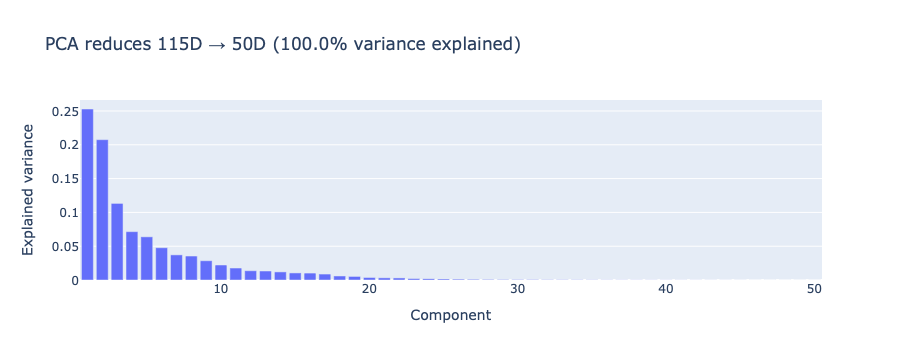

In [7]:
pca = kairo.compute_pca(std_features, num_components=50)
pca_plot = kairo.plot_pca_variances(pca)
pca_plot.show()
#pca

In [8]:
compressed_features = kairo.apply_pca(std_features, pca, cut_component=13)
compressed_features

,case:concept:name,time:timestamp,pc_1,pc_2,pc_3,pc_4,pc_5,pc_6,pc_7,pc_8,pc_9,pc_10,pc_11,pc_12,pc_13
0,case_000000,2017-05-29 08:49:25+00:00,-1.479990,-0.393453,-0.803889,-0.225304,-0.178530,0.327245,-0.501438,-0.215653,-0.267268,-0.115837,-0.059156,0.025088,-0.085787
1,case_000000,2017-05-29 08:52:49+00:00,-1.448551,0.484035,-0.116427,0.223079,0.198966,-0.509641,-0.131702,1.075069,0.750329,-0.464401,0.361062,-0.132697,-0.290555
2,case_000000,2017-05-29 09:02:39+00:00,-1.057344,0.903372,0.711988,0.627993,0.498052,-0.749163,-0.222386,-0.145608,-0.694494,0.391446,0.597275,-0.118122,0.308936
3,case_000000,2017-05-29 11:23:33+00:00,-0.501294,1.246955,1.285447,0.374433,0.154020,1.041550,0.080662,0.028620,0.184669,0.144771,-0.177328,0.085109,-0.113696
4,case_000000,2017-05-31 09:26:08+00:00,-0.341880,1.248738,1.148390,-0.147339,-0.371276,0.088747,-0.141289,0.058532,-0.137768,-0.144888,0.056314,0.737973,-0.191332
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212716,case_032426,2019-03-06 14:59:39+00:00,-1.200793,-0.270184,-0.661585,-0.035463,-0.046257,-0.267132,0.531438,0.570911,0.551734,-0.054681,-0.613459,0.875256,1.653444
212717,case_032427,2019-03-06 15:01:31+00:00,-1.390102,-0.359147,-0.812277,-0.225946,-0.194731,0.323122,-0.469121,-0.200906,-0.239350,-0.088858,-0.059782,0.086458,0.030800
212718,case_032427,2019-03-06 15:01:31+00:00,-1.200793,-0.270184,-0.661585,-0.035463,-0.046257,-0.267132,0.531438,0.570911,0.551734,-0.054681,-0.613459,0.875256,1.653444
212719,case_032428,2019-03-06 16:38:59+00:00,-1.390102,-0.359147,-0.812277,-0.225946,-0.194731,0.323122,-0.469121,-0.200906,-0.239350,-0.088858,-0.059782,0.086458,0.030800


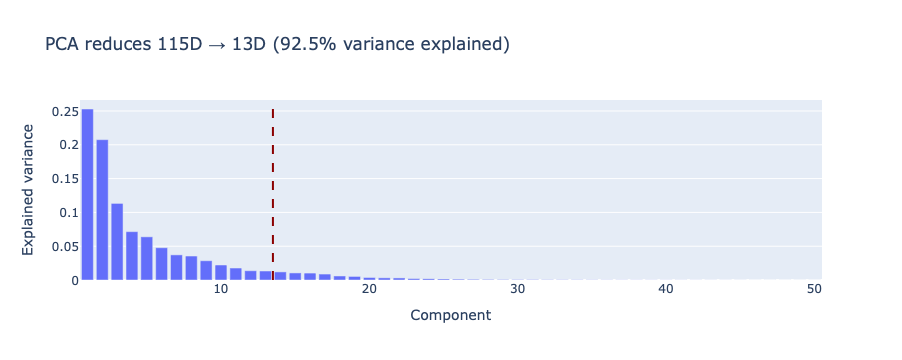

In [9]:
pca_plot_cut = kairo.plot_pca_variances(pca, cut_component=13)
pca_plot_cut.show()

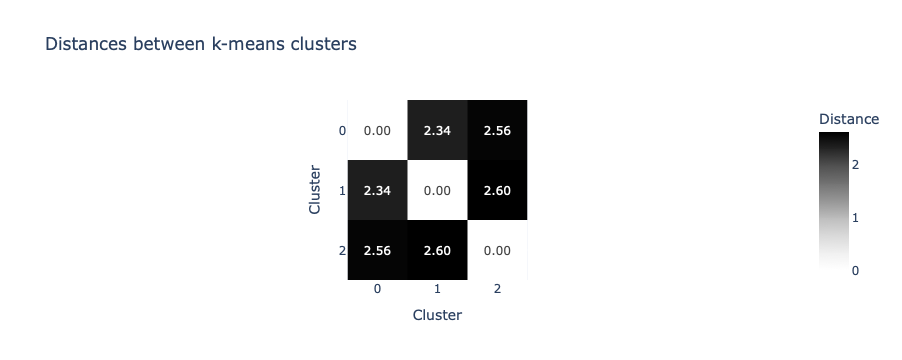

In [10]:
kmeans = kairo.compute_kmeans(compressed_features, k=3)
distances = kairo.plot_kmeans_distances(kmeans)
distances.show()

In [11]:
clusters = kairo.get_kmeans_clusters(compressed_features, kmeans)
clusters

,cluster
0,0
1,0
2,0
3,1
4,1
...,...
212716,0
212717,0
212718,0
212719,0


In [12]:
features_and_clusters = pd.concat([compressed_features, clusters], axis=1)
features_and_clusters

,case:concept:name,time:timestamp,pc_1,pc_2,pc_3,pc_4,pc_5,pc_6,pc_7,pc_8,pc_9,pc_10,pc_11,pc_12,pc_13,cluster
0,case_000000,2017-05-29 08:49:25+00:00,-1.479990,-0.393453,-0.803889,-0.225304,-0.178530,0.327245,-0.501438,-0.215653,-0.267268,-0.115837,-0.059156,0.025088,-0.085787,0
1,case_000000,2017-05-29 08:52:49+00:00,-1.448551,0.484035,-0.116427,0.223079,0.198966,-0.509641,-0.131702,1.075069,0.750329,-0.464401,0.361062,-0.132697,-0.290555,0
2,case_000000,2017-05-29 09:02:39+00:00,-1.057344,0.903372,0.711988,0.627993,0.498052,-0.749163,-0.222386,-0.145608,-0.694494,0.391446,0.597275,-0.118122,0.308936,0
3,case_000000,2017-05-29 11:23:33+00:00,-0.501294,1.246955,1.285447,0.374433,0.154020,1.041550,0.080662,0.028620,0.184669,0.144771,-0.177328,0.085109,-0.113696,1
4,case_000000,2017-05-31 09:26:08+00:00,-0.341880,1.248738,1.148390,-0.147339,-0.371276,0.088747,-0.141289,0.058532,-0.137768,-0.144888,0.056314,0.737973,-0.191332,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212716,case_032426,2019-03-06 14:59:39+00:00,-1.200793,-0.270184,-0.661585,-0.035463,-0.046257,-0.267132,0.531438,0.570911,0.551734,-0.054681,-0.613459,0.875256,1.653444,0
212717,case_032427,2019-03-06 15:01:31+00:00,-1.390102,-0.359147,-0.812277,-0.225946,-0.194731,0.323122,-0.469121,-0.200906,-0.239350,-0.088858,-0.059782,0.086458,0.030800,0
212718,case_032427,2019-03-06 15:01:31+00:00,-1.200793,-0.270184,-0.661585,-0.035463,-0.046257,-0.267132,0.531438,0.570911,0.551734,-0.054681,-0.613459,0.875256,1.653444,0
212719,case_032428,2019-03-06 16:38:59+00:00,-1.390102,-0.359147,-0.812277,-0.225946,-0.194731,0.323122,-0.469121,-0.200906,-0.239350,-0.088858,-0.059782,0.086458,0.030800,0


In [18]:
state_distances = kairo.get_kmeans_state_distances(kmeans)
state_distances

,0,1,2
0,0.000000,2.335956,2.560887
1,2.335956,0.000000,2.601346
2,2.560887,2.601346,0.000000


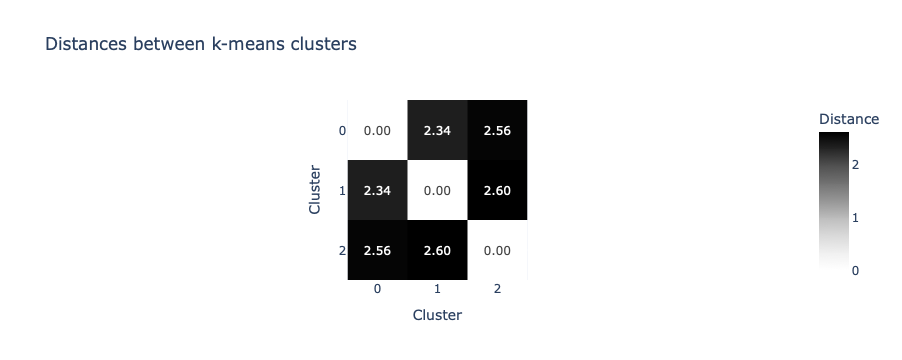

In [20]:
distances_plot = kairo.plot_kmeans_distances(kmeans)
distances_plot.show()

In [23]:
color_mapping = kairo.compute_kmeans_color_mapping(3)

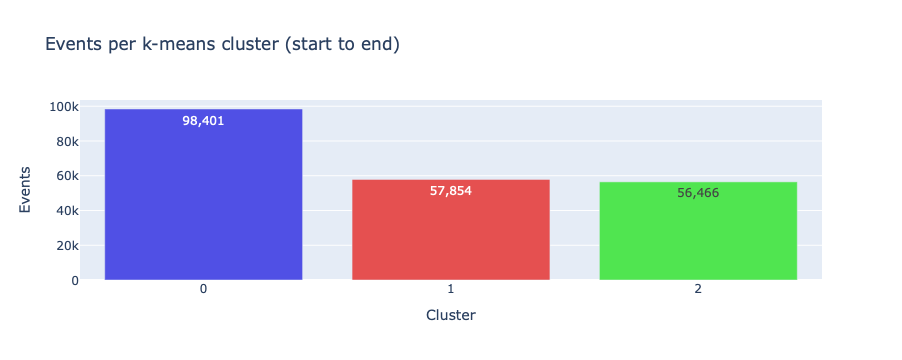

In [24]:
freqs_plot = kairo.plot_kmeans_frequencies(features_and_clusters, color_mapping)
freqs_plot.show()

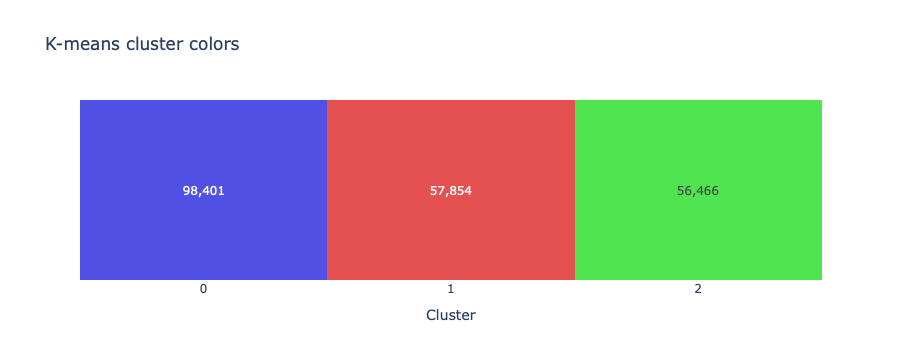

In [25]:
state_colors_plot = kairo.plot_kmeans_colors(features_and_clusters, color_mapping)
state_colors_plot.show()

In [29]:
case_trajectory = kairo.get_kmeans_case_trajectory(features_and_clusters, case_id="case_000001")
case_trajectory

,state,start,end,duration,events
0,0,2017-06-05 13:34:59+00:00,2017-06-14 10:11:14+00:00,8 days 20:36:15,3
1,2,2017-06-14 10:11:14+00:00,2018-09-13 08:57:36+00:00,455 days 22:46:22,9


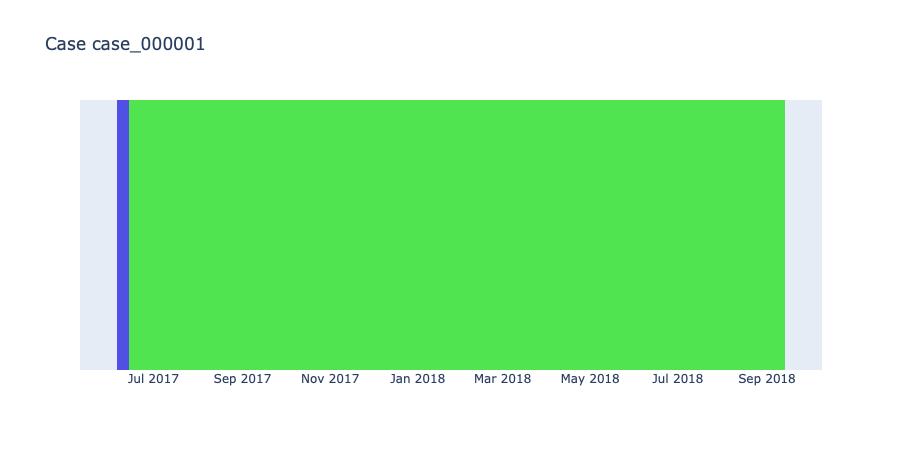

In [30]:
case_trajectory_plot = kairo.plot_kmeans_case_trajectory(features_and_clusters, color_mapping, case_id="case_000001")
case_trajectory_plot

In [32]:
case_trajectories = kairo.get_kmeans_trajectories(features_and_clusters, max_cases=10)
case_trajectories

,case,state,start,end,duration,events
0,case_000000,0,2017-05-29 08:49:25+00:00,2017-05-29 11:23:33+00:00,0 days 02:34:08,3
1,case_000000,1,2017-05-29 11:23:33+00:00,2017-06-15 03:04:22+00:00,16 days 15:40:49,6
2,case_000001,0,2017-06-05 13:34:59+00:00,2017-06-14 10:11:14+00:00,8 days 20:36:15,3
3,case_000001,2,2017-06-14 10:11:14+00:00,2018-09-13 08:57:36+00:00,455 days 22:46:22,9
4,case_000004,0,2017-07-12 10:34:30+00:00,2018-09-14 12:28:55+00:00,429 days 01:54:25,3
5,case_000004,1,2018-09-14 12:28:55+00:00,2018-09-18 03:03:16+00:00,3 days 14:34:21,4
6,case_000005,0,2017-07-13 09:05:45+00:00,2018-02-26 13:03:07+00:00,228 days 03:57:22,3
7,case_000005,2,2018-02-26 13:03:07+00:00,2018-09-19 03:03:26+00:00,204 days 14:00:19,6
8,case_000006,0,2017-07-14 09:11:16+00:00,2018-09-13 12:23:19+00:00,426 days 03:12:03,3
9,case_000006,1,2018-09-13 12:23:19+00:00,2018-09-15 03:04:17+00:00,1 days 14:40:58,4


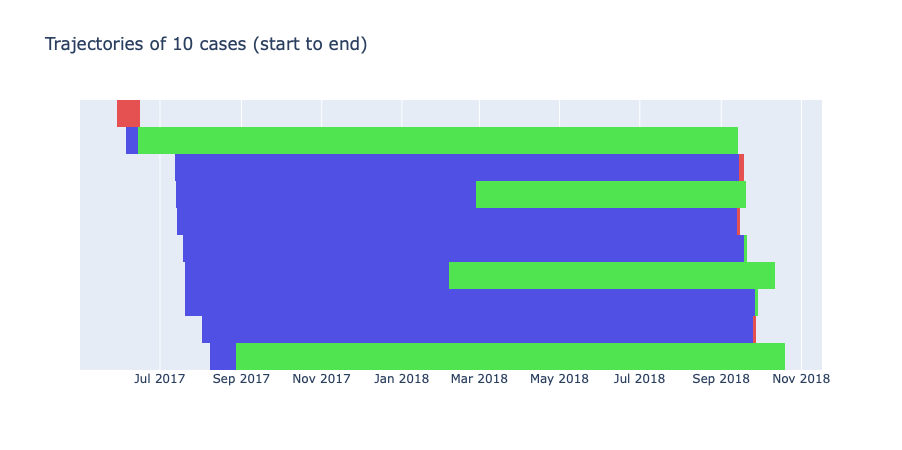

In [34]:
case_trajectories_plot = kairo.plot_kmeans_trajectories(features_and_clusters, color_mapping, max_cases=10)
case_trajectories_plot

In [35]:
freq_distributions = kairo.compute_state_distributions(features_and_clusters, window="30D")
freq_distributions

state,0,1,2
window,,,
2017-05-24 00:00:00+00:00,0.461538,0.461538,0.076923
2017-06-23 00:00:00+00:00,1.000000,0.000000,0.000000
2017-07-23 00:00:00+00:00,1.000000,0.000000,0.000000
2017-08-22 00:00:00+00:00,0.888889,0.000000,0.111111
2017-09-21 00:00:00+00:00,0.870968,0.000000,0.129032
2017-10-21 00:00:00+00:00,0.771429,0.000000,0.228571
2017-11-20 00:00:00+00:00,0.767442,0.069767,0.162791
2017-12-20 00:00:00+00:00,0.842105,0.000000,0.157895
2018-01-19 00:00:00+00:00,0.831325,0.012048,0.156627


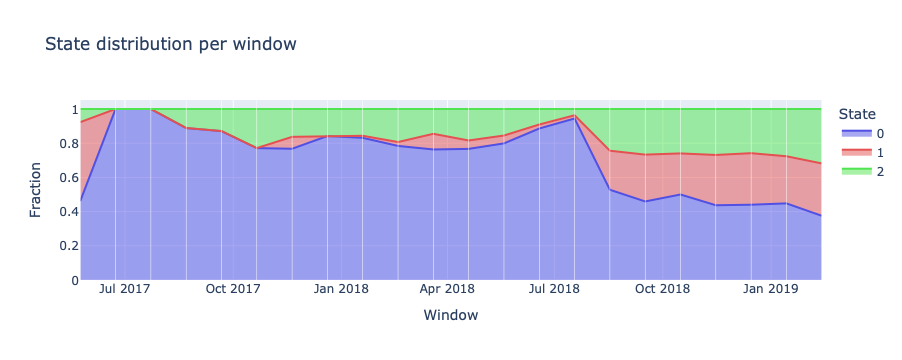

In [36]:
distributions_plot = kairo.plot_state_distributions(freq_distributions, color_mapping)
distributions_plot.show()

In [37]:
divergences = kairo.compute_divergences(freq_distributions)
divergences

,window,score
0,2017-05-24 00:00:00+00:00,NaN
1,2017-06-23 00:00:00+00:00,0.773190
2,2017-07-23 00:00:00+00:00,0.000000
3,2017-08-22 00:00:00+00:00,1.953753
4,2017-09-21 00:00:00+00:00,0.001555
5,2017-10-21 00:00:00+00:00,0.037073
6,2017-11-20 00:00:00+00:00,1.200822
7,2017-12-20 00:00:00+00:00,0.073361
8,2018-01-19 00:00:00+00:00,0.184465
9,2018-02-18 00:00:00+00:00,0.009081


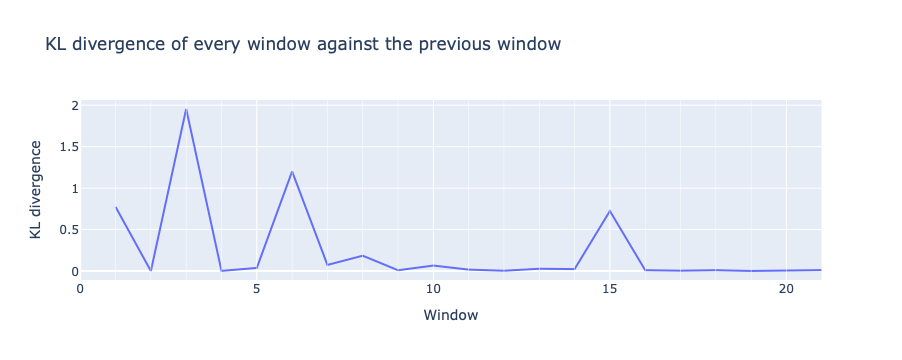

In [38]:
divergences_plot = kairo.plot_divergences(divergences)
divergences_plot.show()

In [39]:
abs_log_stats = kairo.abstract_log_stats(stats)
abs_log_stats

'Event log: 212,721 events of 32,429 cases, 15 activities and 654 resources, from 2017-05-29 08:49:25+00:00 to 2019-03-06 16:38:59+00:00.\nThroughput time per case in days: min 0.00, mean 13.46, median 6.07, max 503.59.\nEvents per case: min 2, mean 6.6, median 7.0, max 23.\nEvents per activity: Request created (32,377), Service closure Request with BO responsibility (30,130), Pending Request for Reservation Closure (29,151), Request completed with account closure (29,031), Pending Liquidation Request (29,000), Service closure Request with network responsibility (25,009), Authorization Requested (12,675), Evaluating Request (NO registered letter) (11,080), Back-Office Adjustment Requested (3,363), Request deleted (3,312), Network Adjustment Requested (2,252), Evaluating Request (WITH registered letter) (2,207), Pending Request for acquittance of heirs (2,119), Pending Request for Network Information (929), Request completed with customer recovery (86)\nMost active resources: BOF (113,9

In [40]:
abs_log_stats = kairo.abstract_log_stats(stats)
abs_log_stats

'Event log: 212,721 events of 32,429 cases, 15 activities and 654 resources, from 2017-05-29 08:49:25+00:00 to 2019-03-06 16:38:59+00:00.\nThroughput time per case in days: min 0.00, mean 13.46, median 6.07, max 503.59.\nEvents per case: min 2, mean 6.6, median 7.0, max 23.\nEvents per activity: Request created (32,377), Service closure Request with BO responsibility (30,130), Pending Request for Reservation Closure (29,151), Request completed with account closure (29,031), Pending Liquidation Request (29,000), Service closure Request with network responsibility (25,009), Authorization Requested (12,675), Evaluating Request (NO registered letter) (11,080), Back-Office Adjustment Requested (3,363), Request deleted (3,312), Network Adjustment Requested (2,252), Evaluating Request (WITH registered letter) (2,207), Pending Request for acquittance of heirs (2,119), Pending Request for Network Information (929), Request completed with customer recovery (86)\nMost active resources: BOF (113,9

In [41]:
abs_features = kairo.abstract_features(features)
abs_features

'Intra-case feature matrix: 212,721 rows, one per event, each describing its case up to and including that event, with 115 feature columns.\nThe events belong to 32,429 cases.\nThey happened from 2017-05-29 08:49:25+00:00 to 2019-03-06 16:38:59+00:00.\nFeature groups:\n- act_freqs (share of every activity among the events of the case so far): 15 columns, mean value 0.067, non-zero in 26.4% of the cells, highest column means act_freqs:Request created = 0.378, act_freqs:Service closure Request with network responsibility = 0.162, act_freqs:Service closure Request with BO responsibility = 0.118\n- df_counts (how often every directly-follows pair happened in the case so far): 54 columns, mean value 0.056, non-zero in 5.6% of the cells, highest column means df_counts:Service closure Request with BO responsibility -> Pending Request for Reservation Closure = 0.419, df_counts:Request created -> Service closure Request with network responsibility = 0.387, df_counts:Service closure Request with

In [42]:
abs_pca = kairo.abstract_pca(pca, cut_component=13)
abs_pca

'PCA fitted 50 components on 115 feature columns. The cut keeps the first 13, which explain 92.5% of the variance.\nExplained variance per component: pc_1 25.3%, pc_2 20.8%, pc_3 11.3%, pc_4 7.2%, pc_5 6.4%, pc_6 4.8%, pc_7 3.7%, pc_8 3.5%, pc_9 2.8%, pc_10 2.2%, pc_11 1.8%, pc_12 1.4%, pc_13 1.3%, pc_14 1.2%, pc_15 1.0%, pc_16 1.0%, pc_17 0.9%, pc_18 0.6%, pc_19 0.5%, pc_20 0.4%, pc_21 0.3%, pc_22 0.3%, pc_23 0.2%, pc_24 0.2%, pc_25 0.1%, pc_26 0.1%, pc_27 0.1%, pc_28 0.1%, pc_29 0.1%, pc_30 0.1%, pc_31 0.0%, pc_32 0.0%, pc_33 0.0%, pc_34 0.0%, pc_35 0.0%, pc_36 0.0%, pc_37 0.0%, pc_38 0.0%, pc_39 0.0%, pc_40 0.0%, pc_41 0.0%, pc_42 0.0%, pc_43 0.0%, pc_44 0.0%, pc_45 0.0%, pc_46 0.0%, pc_47 0.0%, pc_48 0.0%, pc_49 0.0%, pc_50 0.0%\nFeatures with the strongest loadings on every kept component:\n- pc_1: act_set:Pending Request for Reservation Closure (+0.34), act_set:Service closure Request with BO responsibility (+0.34), act_set:Pending Liquidation Request (+0.30), df_counts:Pending R

In [43]:
abs_states = kairo.abstract_states(features_and_clusters, state_distances, color_mapping)
abs_states

'3 states occur among the 212,721 events. Events per state:\n- 0: 98,401 events (46.3%)\n- 1: 57,854 events (27.2%)\n- 2: 56,466 events (26.5%)\nNearest and farthest other state for every state, by the distance between them:\n- 0: nearest 1 (2.34), farthest 2 (2.56)\n- 1: nearest 0 (2.34), farthest 2 (2.60)\n- 2: nearest 0 (2.56), farthest 1 (2.60)\nColors of the states in the plots:\n- 0: #5050e5 (blue)\n- 1: #e55050 (red)\n- 2: #50e550 (green)'

In [44]:
abs_case_trajectory = kairo.abstract_case_trajectory(case_trajectory, "case_000001")
abs_case_trajectory

'Trajectory of case case_000001, one line per visit of a state, in order:\n- 0 from 2017-06-05 13:34:59+00:00 to 2017-06-14 10:11:14+00:00 (8 days 20:36:15, 3 events)\n- 2 from 2017-06-14 10:11:14+00:00 to 2018-09-13 08:57:36+00:00 (455 days 22:46:22, 9 events)'